<a href="https://colab.research.google.com/github/Chitlangia-Vedant/CNN-Image-Classification/blob/main/ML_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks

In [ ]:
# Imports
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import random
import sys
import os
import numpy as np
from tensorflow.python.keras.utils.data_utils import get_file
from tensorflow.python.keras import backend as K
from tensorflow.keras import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from six.moves import cPickle
from keras.optimizers import SGD
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPooling2D
%matplotlib inline

### **Load the Data**

In [ ]:
# Load function.
""" ciFAIR data loader for tf.keras. Requires tensorflow >= 1.9.

Version: 1.0

https://cvjena.github.io/cifair/
"""
def load_cifair10():
    """Loads [ciFAIR-10 dataset](https://cvjena.github.io/cifair/).

    This is a variant of the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)
    dataset with a duplicate-free test set.
    See the [ciFAIR homepage](https://cvjena.github.io/cifair/) for more information.

    Returns:
        Tuple of Numpy arrays: `(x_train, y_train), (x_test, y_test)`.

        **x_train, x_test**: uint8 arrays of RGB image data with shape
            `(num_samples, 3, 32, 32)` if `tf.keras.backend.image_data_format()` is
            `'channels_first'`, or `(num_samples, 32, 32, 3)` if the data format
            is `'channels_last'`.

        **y_train, y_test**: uint8 arrays of category labels
            (integers in range 0-9) each with shape (num_samples, 1).
    """
    dirname = 'ciFAIR-10'
    archive_name = 'ciFAIR-10.zip'
    origin = 'https://github.com/cvjena/cifair/releases/download/v1.0/ciFAIR-10.zip'
    md5_hash = 'ca08fd390f0839693d3fc45c4e49585f'

    path = get_file(archive_name, origin=origin, file_hash=md5_hash, hash_algorithm='md5', extract=True, archive_format='zip')
    path = os.path.join(os.path.dirname(path), dirname)

    num_train_samples = 50000

    x_train = np.empty((num_train_samples, 3, 32, 32), dtype='uint8')
    y_train = np.empty((num_train_samples,), dtype='uint8')

    for i in range(1, 6):
        fpath = os.path.join(path, 'data_batch_' + str(i))
        (x_train[(i - 1) * 10000:i * 10000, :, :, :],
        y_train[(i - 1) * 10000:i * 10000]) = _load_batch(fpath)

    fpath = os.path.join(path, 'test_batch')
    x_test, y_test = _load_batch(fpath)

    y_train = np.reshape(y_train, (len(y_train), 1))
    y_test = np.reshape(y_test, (len(y_test), 1))

    if K.image_data_format() == 'channels_last':
        x_train = x_train.transpose(0, 2, 3, 1)
        x_test = x_test.transpose(0, 2, 3, 1)

    x_test = x_test.astype(x_train.dtype)
    y_test = y_test.astype(y_train.dtype)

    return (x_train, y_train), (x_test, y_test)


def _load_batch(fpath, label_key='labels'):
    """Internal utility for parsing ciFAIR data.
    # Arguments
        fpath: path the file to parse.
        label_key: key for label data in the retrieve
            dictionary.
    # Returns
        A tuple `(data, labels)`.
    """
    with open(fpath, 'rb') as f:
        if sys.version_info < (3,):
            d = cPickle.load(f)
            # Encode utf8 to ascii
            d_decoded = {}
            for k, v in d.items():
                d_decoded[k.encode('utf-8') if isinstance(k, unicode) else k] = v
            d = d_decoded
        else:
            d = cPickle.load(f, encoding='bytes')
            # Decode bytes to utf8
            d_decoded = {}
            for k, v in d.items():
                d_decoded[k.decode('utf-8') if isinstance(k, bytes) else k] = v
            d = d_decoded
    data = d['data']
    labels = d[label_key]

    data = data.reshape(data.shape[0], 3, 32, 32)
    return data, labels


Now let's load the dataset and view the shape of our data

In [ ]:
# Load data and split the data between train and test
(x_train, y_train), (x_test, y_test) = load_cifair10()
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

168615936/168614301 [==============================] - 5s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
50000 train samples
10000 test samples


### **Data Preprocessing**

Now I am going to convert the type of the data and normalize them. After that I am going to perform one hot encoding.

In [ ]:
# Connvert data type to float for computation
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Normalize the data
x_train /= 255
x_test /= 255

# Convert class vectors to binary class matrices (One hot encoding)
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
# Print the sample data
print(y_train[:10])

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


Now that we have performed data preprocessing it is time to create the  models.

## **Model 1 (LeNet)**

In [ ]:
# This model is inspired by the original LeNet architecture,
# which was developed for classifying handwritten digits.

# Define the model architecture
LeNet = Sequential()

# Add the convolutional layers
LeNet.add(Conv2D(filters=6, kernel_size=(5, 5), activation='relu', input_shape=(32, 32, 3)))
LeNet.add(MaxPooling2D(pool_size=(2, 2)))
LeNet.add(Conv2D(filters=16, kernel_size=(5, 5), activation='relu'))
LeNet.add(MaxPooling2D(pool_size=(2, 2)))

# Add the fully connected layers
LeNet.add(Flatten())
LeNet.add(Dense(units=120, activation='relu'))
LeNet.add(Dense(units=84, activation='relu'))
LeNet.add(Dense(units=num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
LeNet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

### **Model Training**

In [ ]:
batch_size_le = 64
epochs_le = 30

# Compile AlexNet Model
LeNet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train AlexNet Model
LeHistory = LeNet.fit(x_train, y_train, batch_size=batch_size_le, epochs=epochs_le, validation_data=(x_test,y_test))

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3952 - loss: 1.6578 - val_accuracy: 0.4851 - val_loss: 1.4227
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5066 - loss: 1.3683 - val_accuracy: 0.5141 - val_loss: 1.3449
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5498 - loss: 1.2555 - val_accuracy: 0.5478 - val_loss: 1.2474
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5828 - loss: 1.1682 - val_accuracy: 0.5787 - val_loss: 1.1908
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6066 - loss: 1.1107 - val_accuracy: 0.5711 - val_loss: 1.2162
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6259 - loss: 1.0571 - val_accuracy: 0.5873 - val_loss: 1.1736
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6379 - loss: 1.0189 - val_accuracy: 0.6113 - val_loss: 1.1261
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6555 - loss: 0.9760 - val_accuracy: 0

In [ ]:
# Make Prediction
pred_le = LeNet.predict(x_test)
Y_pred_classes_le = np.argmax(pred_le, axis=1)
Y_true_le = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


### **Model Evaluation**

**Final Metrics**

In [ ]:
# Score trained model
LeNet_test_scores = LeNet.evaluate(x_test, y_test, verbose=1)
LeNet_train_scores = LeNet.evaluate(x_train, y_train, verbose=1)
print(' ')
print('Test Loss:', LeNet_test_scores[0])
print('Test Accuracy:', LeNet_test_scores[1])
print('----------------------------------')
print('Train Loss:', LeNet_train_scores[0])
print('Train Accuracy:', LeNet_train_scores[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6133 - loss: 1.4277
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8413 - loss: 0.4530
 
Test Loss: 1.427679181098938
Test Accuracy: 0.6133000254631042
----------------------------------
Train Loss: 0.4529998004436493
Train Accuracy: 0.8413199782371521


**Plotting Curves**

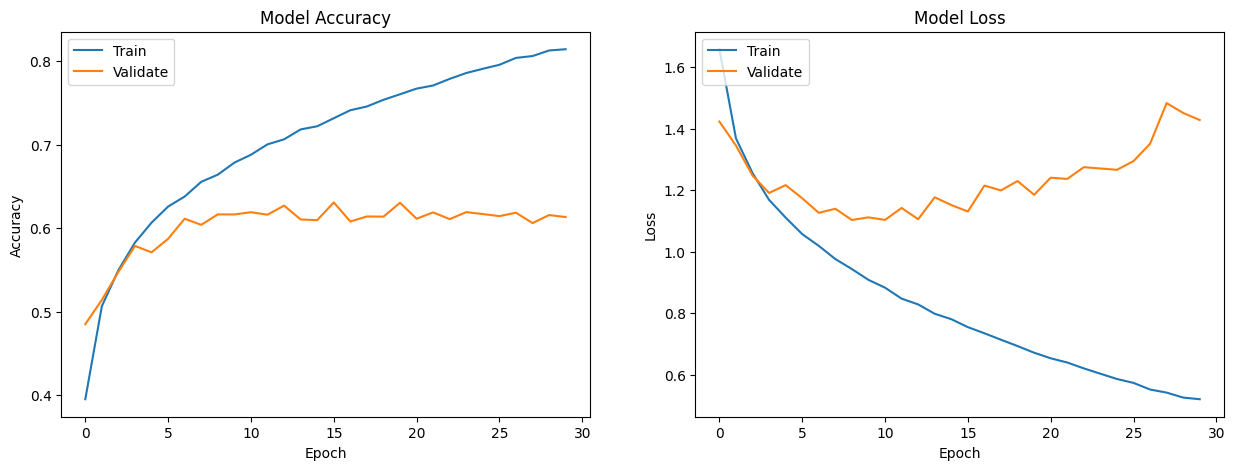

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))
# Summarize history for accuracy
axs[0].plot(LeHistory.history['accuracy'])
axs[0].plot(LeHistory.history['val_accuracy'])
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend(['Train', 'Validate'], loc='upper left')

# Summarize history for loss
axs[1].plot(LeHistory.history['loss'])
axs[1].plot(LeHistory.history['val_loss'])
axs[1].set_title('Model Loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend(['Train', 'Validate'], loc='upper left')
plt.show()

**Confusion Matrix**

In [ ]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
cm = confusion_matrix(Y_true_le, Y_pred_classes_le)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 10))
disp = disp.plot(xticks_rotation=45, ax=ax,cmap='Blues')
plt.title('LeNet Confusion Matrix', fontsize=18)
plt.show()

**Classification report**

In [ ]:
print(classification_report(Y_true_le, Y_pred_classes_le))

              precision    recall  f1-score   support

           0       0.62      0.72      0.67      1000
           1       0.70      0.70      0.70      1000
           2       0.54      0.51      0.52      1000
           3       0.44      0.40      0.42      1000
           4       0.61      0.49      0.54      1000
           5       0.48      0.56      0.52      1000
           6       0.73      0.63      0.67      1000
           7       0.64      0.70      0.67      1000
           8       0.71      0.73      0.72      1000
           9       0.67      0.69      0.68      1000

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.61      0.61      0.61     10000



## **Model 2 (VGGNet)**

In [ ]:
# This model is inspired by the VGGNet architecture,
# which was developed for different use cases.

VGGNet = Sequential()

# Block 1
VGGNet.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
VGGNet.add(Activation('relu'))
VGGNet.add(Conv2D(32, (3, 3), padding='same'))
VGGNet.add(Activation('relu'))
VGGNet.add(MaxPooling2D(pool_size=(2, 2)))
VGGNet.add(Dropout(0.25))

# Block 2
VGGNet.add(Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3)))
VGGNet.add(Activation('relu'))
VGGNet.add(Conv2D(64, (3, 3), padding='same'))
VGGNet.add(Activation('relu'))
VGGNet.add(MaxPooling2D(pool_size=(2, 2)))
VGGNet.add(Dropout(0.25))

# Block 3
VGGNet.add(Conv2D(128, (3, 3), padding='same'))
VGGNet.add(Activation('relu'))
VGGNet.add(Conv2D(128, (3, 3), padding='same'))
VGGNet.add(Activation('relu'))
VGGNet.add(MaxPooling2D(pool_size=(2, 2)))
VGGNet.add(Dropout(0.25))

# Classification block
VGGNet.add(Flatten())
VGGNet.add(Dense(4096))
VGGNet.add(Activation('relu'))
VGGNet.add(Dropout(0.5))
VGGNet.add(Dense(4096))
VGGNet.add(Activation('relu'))
VGGNet.add(Dropout(0.5))
VGGNet.add(Dense(10))
VGGNet.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Model Summary
VGGNet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             

 Total params: 25,501,994 (97.28 MB)

 Trainable params: 25,501,994 (97.28 MB)

 Non-trainable params: 0 (0.00 B)

### **Model Training**

In [ ]:
batch_size_vgg = 64
epochs_vgg = 30

# Compile VGGNet Model
VGGNet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train VGGNet Model
VggHistory = VGGNet.fit(x_train, y_train, batch_size=batch_size_vgg, epochs=epochs_vgg, validation_data=(x_test,y_test))

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.3147 - loss: 1.8039 - val_accuracy: 0.4893 - val_loss: 1.3886
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.5166 - loss: 1.3343 - val_accuracy: 0.5949 - val_loss: 1.1379
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.5820 - loss: 1.1632 - val_accuracy: 0.5982 - val_loss: 1.1237
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6226 - loss: 1.0628 - val_accuracy: 0.6358 - val_loss: 1.0087
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6547 - loss: 0.9780 - val_accuracy: 0.6760 - val_loss: 0.9207
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6716 - loss: 0.9306 - val_accuracy: 0.6888 - val_loss: 0.8800
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6876 - loss: 0.8943 - val_accuracy: 0.7036 - val_loss: 0.8432
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6980 - loss: 0.8610 - 

In [ ]:
# Make Prediction
pred_vgg = VGGNet.predict(x_test)
Y_pred_classes_vgg = np.argmax(pred_vgg, axis=1)
Y_true_vgg = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


### **Model Evaluation**

**Model Metrics**

In [ ]:
# Training and Testing Scores
VGGNet_test_scores = VGGNet.evaluate(x_test, y_test, verbose=1)
VGGNet_train_scores = VGGNet.evaluate(x_train, y_train, verbose=1)
print(' ')
print('Test Loss:', VGGNet_test_scores[0])
print('Test Accuracy:', VGGNet_test_scores[1])
print('----------------------------------')
print('Train Loss:', VGGNet_train_scores[0])
print('Train Accuracy:', VGGNet_train_scores[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7677 - loss: 0.6909
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8487 - loss: 0.4661
 
Test Loss: 0.6909259557723999
Test Accuracy: 0.7677000164985657
----------------------------------
Train Loss: 0.4661256968975067
Train Accuracy: 0.8486999869346619


**Plotting Curves**

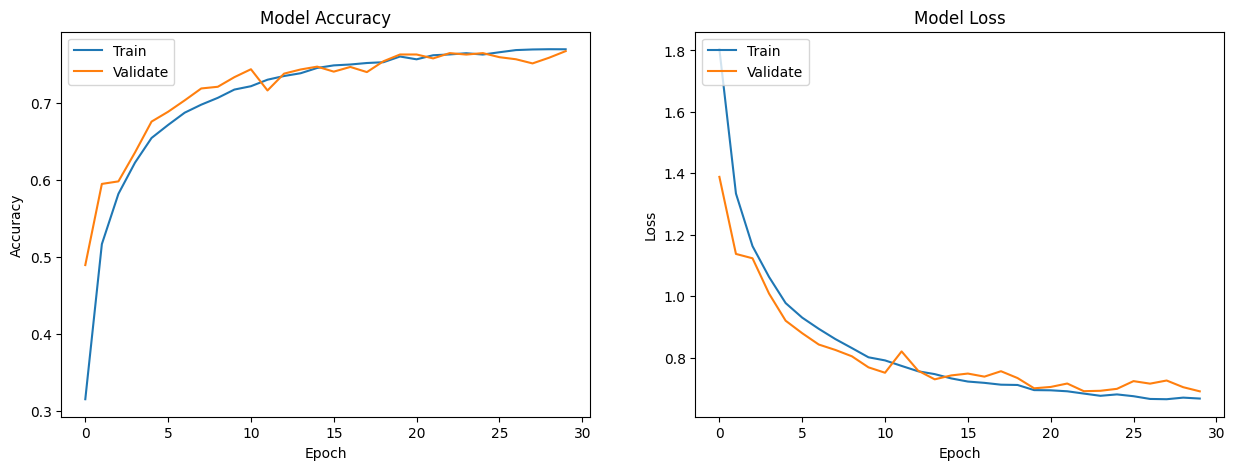

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))
# Summarize history for accuracy
axs[0].plot(VggHistory.history['accuracy'])
axs[0].plot(VggHistory.history['val_accuracy'])
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend(['Train', 'Validate'], loc='upper left')

# Summarize history for loss
axs[1].plot(VggHistory.history['loss'])
axs[1].plot(VggHistory.history['val_loss'])
axs[1].set_title('Model Loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend(['Train', 'Validate'], loc='upper left')
plt.show()

**Confusion Matrix**

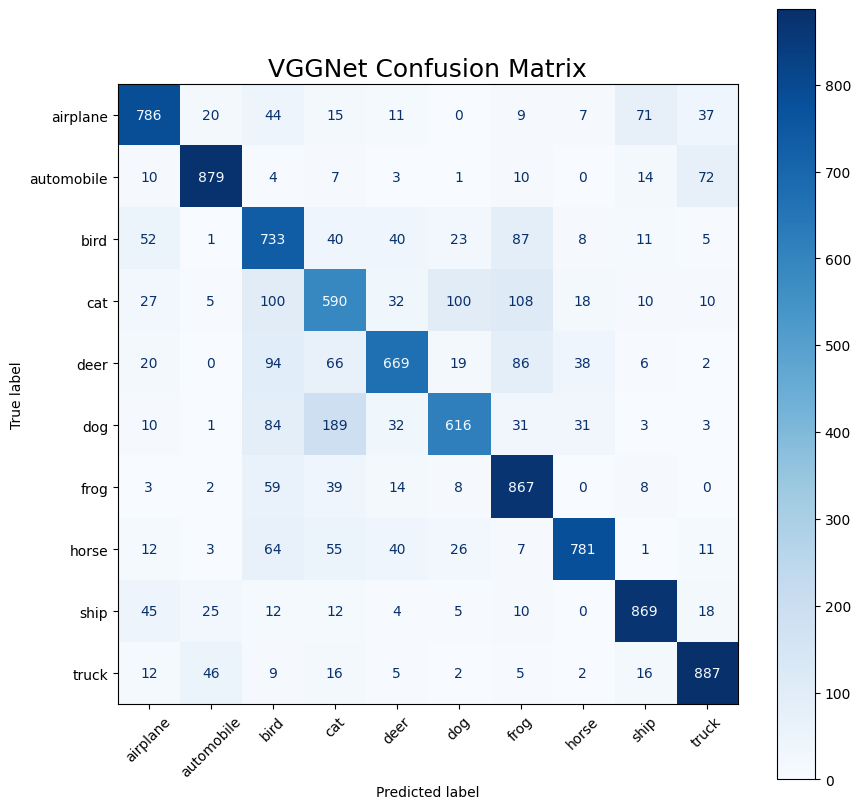

In [ ]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
cm = confusion_matrix(Y_true_vgg, Y_pred_classes_vgg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 10))
disp = disp.plot(xticks_rotation=45, ax=ax,cmap='Blues')
plt.title('VGGNet Confusion Matrix', fontsize=18)
plt.show()

**Classification report**

In [ ]:
print(classification_report(Y_true_vgg, Y_pred_classes_vgg))

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1000
           1       0.90      0.88      0.89      1000
           2       0.61      0.73      0.67      1000
           3       0.57      0.59      0.58      1000
           4       0.79      0.67      0.72      1000
           5       0.77      0.62      0.68      1000
           6       0.71      0.87      0.78      1000
           7       0.88      0.78      0.83      1000
           8       0.86      0.87      0.87      1000
           9       0.85      0.89      0.87      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



## **Compare the Models**

**Plotting the Accuracy curves for each model**

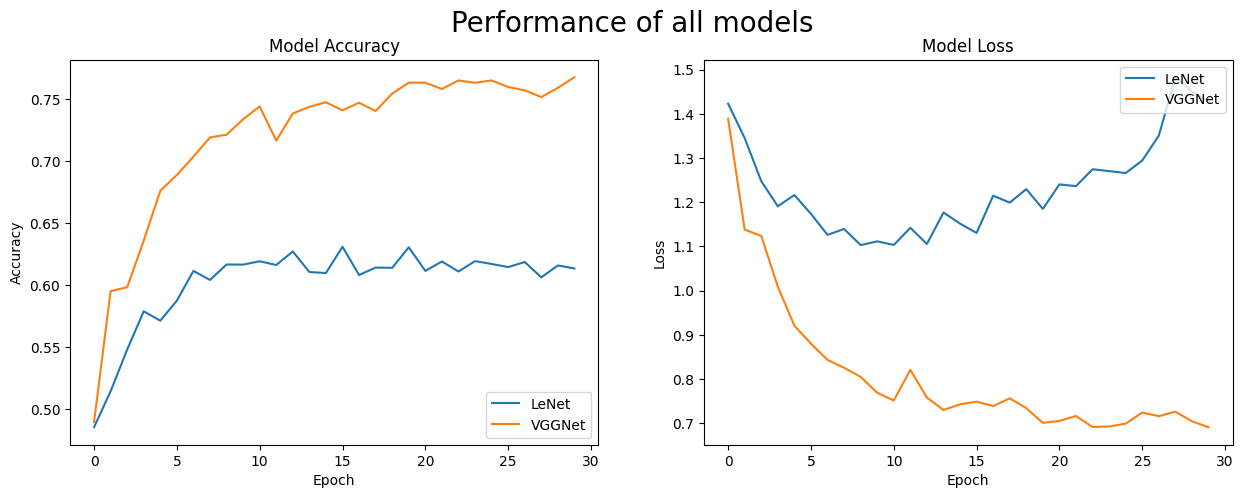

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))
# Summarize history for accuracy


axs[0].plot(LeHistory.history['val_accuracy'])
axs[0].plot(VggHistory.history['val_accuracy'])
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend(['LeNet', 'VGGNet'], loc='lower right')

# Summarize history for loss

axs[1].plot(LeHistory.history['val_loss'])
axs[1].plot(VggHistory.history['val_loss'])
axs[1].set_title('Model Loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend(['LeNet', 'VGGNet'], loc='upper right')
fig.suptitle('Performance of all models', fontsize=20)
plt.show()

GUI

In [33]:
VGGNet.save("/content/vgg_model.h5")

In [38]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model("/content/vgg_model.h5")

labels = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

def predict(img):

    img = np.array(img)
    img = tf.image.resize(img, (32,32))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred)

    return labels[class_id]


gr.Interface(
    fn=predict,
    inputs=gr.Image(),
    outputs="text",
    title="VGG CIFAR10 Model"
).launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1b396ae52164fce62.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
